In [2]:
import joblib

paths = [(r"D:\maldi\slides\slide2_notol_5_bin\0.npy", 1),
        (r"D:\maldi\slides\slide2_notol_5_bin\1.npy", 2),
        (r"D:\maldi\slides\slide2_notol_5_bin\2.npy", 0),
        (r"D:\maldi\slides\slide2_notol_5_bin\3.npy", 3)]

xgb_model, label_encoder = joblib.load("xgb_model_coarse_coarse_new.pkl")


FileNotFoundError: [Errno 2] No such file or directory: 'xgb_model_coarse_coarse_new.pkl'

In [2]:
import importlib
from PIL import Image
import numpy as np
import tqdm
from msi_visual.supervised.annotations import get_img, get_visualization#, get_detection_mask
import msi_visual
importlib.reload(msi_visual)
from msi_visual.visualizations import compare_two_regions
from msi_visual.extraction import get_extraction_mz_list

def get_differences(X, labels, extraction_mzs):
    unique_labels = list(set(labels))
    stats = {}
    for i in range(len(unique_labels)):
        for j in range(i+1, len(unique_labels)):
            
            if unique_labels[i].split("_")[1] != unique_labels[j].split("_")[1]:
                continue

            indices = [index for index in range(len(labels)) if labels[index] == unique_labels[i]]
            a = X[indices, :]
            indices = [index for index in range(len(labels)) if labels[index] == unique_labels[j]]
            b = X[indices, :]

            
            res = compare_two_regions(a, b, mzs=extraction_mzs, use_all_peaks=True)
            #res = {mz : res[mz] for mz in res if res[mz] > 0.8 or res[mz] < 0.3}
            stats[(unique_labels[i], unique_labels[j])] = res
    return stats

def analyze_differences(xgb_model, label_encoder, paths, keep = []):
    N = len(label_encoder.classes_)
    X = []

    average_X = []
    average_labels = []

    labels = []
    for mouse_index, (path, index) in tqdm.tqdm(enumerate(paths)):
        annotation_index = path.split("\\")[-1].split(".")[0]
        img = get_img(path)
        rotated = img.transpose().transpose(1, 2, 0)[::-1, :, :]
        print(rotated.shape)
        predictions = xgb_model.predict(rotated.reshape(-1, rotated.shape[-1])).reshape(rotated.shape[:2])
        print("predictions", predictions.shape)
        for i in range(N):
            label = label_encoder.inverse_transform([i])[0]
            if label not in keep:
                continue

            mask = (predictions == i)
            f = rotated[mask > 0]
            if f.shape[0] == 0:
                continue
            X.append(f)
            labels.extend( [str(mouse_index) + "_" + str(label)] * len(f))


            #average_X.append(f.mean(axis=0))
            average_labels.append(str(mouse_index) + "_" + str(label))

        del img, rotated, predictions
    X = np.concatenate(X)
    #average_X = np.array(average_X)

    stats = get_differences(X, labels, extraction_mzs)
    return stats, average_X, average_labels


extraction_mzs = get_extraction_mz_list(r"D:\maldi\slides\slide2_notol_5_bin")
stats, average_X, average_labels = analyze_differences(xgb_model, label_encoder, paths, keep = ['BG', 'BS', 'CNU', 'CTX', 'HPF', 'PLEXUS', 'VENTRICLE', 'WM'])
#stats, average_X, average_labels = analyze_differences(xgb_model, label_encoder, paths, keep = ["CTX"])

print(stats)

0it [00:00, ?it/s]

(286, 262, 5255)
predictions (286, 262)


1it [00:06,  6.72s/it]

(331, 248, 5255)
predictions (331, 248)


2it [00:15,  7.81s/it]

(314, 292, 5255)
predictions (314, 292)


3it [00:23,  8.07s/it]

(314, 285, 5255)
predictions (314, 285)


4it [00:31,  7.98s/it]


{('1_CNU', '2_CNU'): {300.0: 0.4264228602662273, 300.6: 0.5210382002180353, 300.8: 0.46228630692517225, 302.8: 0.44756642417168124, 304.4: 0.4726209580136968, 306.0: 0.6553776524870335, 307.0: 0.6422602488084643, 307.6: 0.5373605620464481, 308.0: 0.6119688143506844, 309.0: 0.5714193114370406, 309.2: 0.3979771673635853, 311.2: 0.5572097292979125, 313.0: 0.5487553570302356, 314.8: 0.4650670573548859, 315.2: 0.5554706027804001, 316.8: 0.4414120335842374, 317.2: 0.5546329489519192, 318.4: 0.5201016897232114, 318.8: 0.4499722700794157, 320.8: 0.46671408449717244, 322.0: 0.6390710576712273, 323.0: 0.7887760894004631, 323.4: 0.5252847822800802, 324.0: 0.6038115126221193, 327.2: 0.6621459554859693, 327.4: 0.5315049938884056, 328.2: 0.5691783934865721, 329.2: 0.5744573394692873, 330.8: 0.4712334609043158, 331.2: 0.44880801384694086, 331.6: 0.47346712102358446, 334.6: 0.46355517603494173, 335.8: 0.5267238350179844, 338.2: 0.5501280882071755, 339.0: 0.6856508172317931, 340.0: 0.5517188045901528, 

In [48]:
def get_filtered_mzs(stats, prefix, group_a, group_b):
    result = {}
    for a, b in stats:
        result[a, b] = {mz: stats[a, b][mz] for mz in stats[a, b] if stats[a, b][mz] > 0.5}
        result[b, a] = {mz: stats[a, b][mz] for mz in stats[a, b] if stats[a, b][mz] < 0.5}
        

    a = set(list(result[(f"{group_a[0]}_{prefix}", f"{group_b[0]}_{prefix}")].keys())).intersection(list(result[(f"{group_a[0]}_{prefix}", f"{group_b[1]}_{prefix}")].keys()))
    b = set(list(result[(f"{group_a[1]}_{prefix}", f"{group_b[0]}_{prefix}")].keys())).intersection(list(result[(f"{group_a[1]}_{prefix}", f"{group_b[1]}_{prefix}")].keys()))

    mzs = a.intersection(b)
    filtered = []
    for mz in mzs:
        all = np.array(list([result[(f"{group_a[0]}_{prefix}", f"{group_b[0]}_{prefix}")][mz], result[(f"{group_a[0]}_{prefix}", f"{group_b[1]}_{prefix}")][mz], result[(f"{group_a[1]}_{prefix}", f"{group_b[0]}_{prefix}")][mz], result[(f"{group_a[1]}_{prefix}", f"{group_b[1]}_{prefix}")][mz]]))
        filtered.append(mz)
        # p = np.prod(np.sign(all - 0.5))
        # if p == 1.0:
        #    filtered.append(mz)
    return filtered

print(stats.keys())

print("A7KO Cortex", get_filtered_mzs(stats, "CTX", (0, 1), (2, 3)))
print("A7KO Cortex-", get_filtered_mzs(stats, "CTX", (2, 3), (0, 1)))

print("A7KO HPF", get_filtered_mzs(stats, "HPF", (0, 1), (2, 3)))
print("A7KO HPF-", get_filtered_mzs(stats, "HPF", (2, 3), (0, 1)))

print("A7KO VENTRICLE", get_filtered_mzs(stats, "VENTRICLE", (0, 1), (2, 3)))
print("A7KO VENTRICLE-", get_filtered_mzs(stats, "VENTRICLE", (2, 3), (0, 1)))


print("A7KO WM", get_filtered_mzs(stats, "WM", (0, 1), (2, 3)))
print("A7KO WM-", get_filtered_mzs(stats, "WM", (2, 3), (0, 1)))

print("A7KO CNU", get_filtered_mzs(stats, "CNU", (0, 1), (2, 3)))
print("A7KO CNU-", get_filtered_mzs(stats, "CNU", (2, 3), (0, 1)))


#print("A7KO WM", get_filtered_mzs(stats, "WM", (0, 1), (2, 3)))


print("Alzheimer Cortex", get_filtered_mzs(stats, "CTX", (1, 2), (0, 3)))
print("Alzheimer Cortex-", get_filtered_mzs(stats, "CTX", (0, 3), (1, 2)))
print("Alzheimer HPF", get_filtered_mzs(stats, "HPF", (1, 2), (0, 3)))
#print("Alzheimer HPF", get_filtered_mzs(stats, "HPF", (2, 2), (0, 3)))
print("Alzheimer HPF-", get_filtered_mzs(stats, "HPF", (0, 3), (2, 2)))

print("Alzheimer Cortex 2", get_filtered_mzs(stats, "CTX", (1, 2), (3,0)))






dict_keys([('1_CNU', '2_CNU'), ('1_CNU', '0_CNU'), ('1_CNU', '3_CNU'), ('1_VENTRICLE', '0_VENTRICLE'), ('1_VENTRICLE', '3_VENTRICLE'), ('1_VENTRICLE', '2_VENTRICLE'), ('2_HPF', '3_HPF'), ('2_HPF', '0_HPF'), ('2_HPF', '1_HPF'), ('0_BS', '1_BS'), ('0_BS', '2_BS'), ('0_BS', '3_BS'), ('3_HPF', '0_HPF'), ('3_HPF', '1_HPF'), ('0_WM', '1_WM'), ('0_WM', '3_WM'), ('0_WM', '2_WM'), ('1_WM', '3_WM'), ('1_WM', '2_WM'), ('1_BS', '2_BS'), ('1_BS', '3_BS'), ('2_BS', '3_BS'), ('1_CTX', '2_CTX'), ('1_CTX', '3_CTX'), ('1_CTX', '0_CTX'), ('2_PLEXUS', '3_PLEXUS'), ('2_PLEXUS', '1_PLEXUS'), ('3_WM', '2_WM'), ('2_BG', '3_BG'), ('2_BG', '0_BG'), ('2_BG', '1_BG'), ('3_PLEXUS', '1_PLEXUS'), ('0_VENTRICLE', '3_VENTRICLE'), ('0_VENTRICLE', '2_VENTRICLE'), ('2_CNU', '0_CNU'), ('2_CNU', '3_CNU'), ('2_CTX', '3_CTX'), ('2_CTX', '0_CTX'), ('3_VENTRICLE', '2_VENTRICLE'), ('0_CNU', '3_CNU'), ('3_CTX', '0_CTX'), ('0_HPF', '1_HPF'), ('3_BG', '0_BG'), ('3_BG', '1_BG'), ('0_BG', '1_BG')])
A7KO Cortex [1245.8, 1253.4, 1254.

In [5]:
import msi_visual
importlib.reload(msi_visual)
from msi_visual.visualizations import compare_two_regions

unique_labels = list(set(labels))
for i in range(len(unique_labels)):
    for j in range(i+1, len(unique_labels)):

        indices = [index for index in range(len(labels)) if labels[index] == unique_labels[i]]
        a = X[indices, :]
        indices = [index for index in range(len(labels)) if labels[index] == unique_labels[j]]
        b = X[indices, :]
        stats = compare_two_regions(a, b, mzs=extraction_mzs)
        print(unique_labels[i], unique_labels[j], stats)



NameError: name 'labels' is not defined

In [ ]:
for key in diff:
    stats = diff[key]
    stats = {mz: stats[mz] for mz in stats if stats[mz] > 0.8 or stats[mz] < 0.3}
    diff[key] = stats

for key in diff:
    print(key, diff[key])

NameError: name 'diff' is not defined

In [ ]:
from msi_visual.app.utils.viewer import create_ion_image
extraction_mzs = get_extraction_mz_list(r"D:\maldi\slides\slide2_notol_5_bin")


mzs = [1166.0, 1159.8, 1158.8, 1163.0]
mzs = [965.6]

print(paths)
all_ions = []
for path in ["D:\\maldi\\slides\\slide2_notol_5_bin\\0.npy", "D:\\maldi\\slides\\slide2_notol_5_bin\\1.npy", "D:\\maldi\\slides\\slide2_notol_5_bin\\2.npy", "D:\\maldi\\slides\\slide2_notol_5_bin\\3.npy"]:
    masks = []
    data = np.load(path)
    data = total_ion_count(data)
    rotated = data.transpose().transpose(1, 2, 0)[::-1, :, :]
    mask = rotated.max(axis=-1)
    for mz in mzs:
        index = extraction_mzs.index(mz)
        ion = rotated[:, :, index]
        #ion = ion / np.max(ion)
        ion = ion / np.percentile(ion[:], 100)
        ion = (ion * 255).astype(np.uint8)
        ion = cv2.applyColorMap(ion, cmapy.cmap('magma'))[:, :, ::-1].copy()
        ion[mask == 0] = 0
        #ion, _ = create_ion_image(rotated, mz, extraction_mzs)
        ion = cv2.resize(ion, (262, 286))

        font = cv2.FONT_HERSHEY_SIMPLEX
        bottomLeftCornerOfText = (5, 20)
        fontScale = 0.5
        fontColor = (255, 255, 255)
        thickness = 1
        lineType = 1
        ion = cv2.putText(ion, f"{mz:.3f}",
                                bottomLeftCornerOfText,
                                font,
                                fontScale,
                                fontColor,
                                thickness,
                                lineType)

        if "0.npy" in path or "1.npy" in path:
            ion = cv2.putText(ion, f"A7KO", (5, 50), font, fontScale, fontColor, thickness, lineType)


        masks.append(ion)

    a = np.vstack(masks)
    all_ions.append(np.vstack(masks))
    
    del data, rotated

all_ions = np.hstack(all_ions)
display(Image.fromarray(all_ions))

        

#ion, mz = create_ion_image(img2, mz, extraction_mzs)


2025-02-19 17:57:05.801 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


[('D:\\maldi\\slides\\slide2_notol_5_bin\\0.npy', 1), ('D:\\maldi\\slides\\slide2_notol_5_bin\\1.npy', 2), ('D:\\maldi\\slides\\slide2_notol_5_bin\\2.npy', 0), ('D:\\maldi\\slides\\slide2_notol_5_bin\\3.npy', 3)]


NameError: name 'total_ion_count' is not defined

In [28]:
import joblib
import cv2
import cmapy
from PIL import Image
from msi_visual.extraction import get_extraction_mz_list
import tqdm
import numpy as np
from collections import defaultdict
from msi_visual.supervised.annotations import get_img, get_visualization#, get_detection_mask





paths = [(r"D:\maldi\slides\slide2_notol_5_bin\0.npy", 1),
        (r"D:\maldi\slides\slide2_notol_5_bin\1.npy", 2),
        (r"D:\maldi\slides\slide2_notol_5_bin\2.npy", 0),
        (r"D:\maldi\slides\slide2_notol_5_bin\3.npy", 3)]


xgb_model, label_encoder = joblib.load("xgb_model_coarse_coarse_new.pkl")
extraction_mzs = get_extraction_mz_list(r"D:\maldi\slides\slide2_notol_5_bin")


# mzs = [1160.8, 1161.8, 1162.0, 1163.0, 1165.0]
# mzs += [1160.8, 1162.0, 1163.0, 1165.0, 1141.0, 1142.0, 1143.0]
#interesting mzs: [808.2, 809.2]

mzs = [1160.8, 1161.8, 1162.0, 1163.0]

mzs = [1179.73081311,1207.75938587,480.30869475,1180.73943434,1207.78445573,540.0534138,865.50307848,866.50730465,857.51706004,858.51944986,858.52058908,859.52412677]

mzs = list(set((mzs)))
mzs.sort()
print(mzs)
intensities = defaultdict(list)
ions = {}
gallery_images = []
for mouse_index, (path, index) in tqdm.tqdm(enumerate(paths)):
    img = get_img(path)
    pred = xgb_model.predict(img.reshape(-1, img.shape[-1])).reshape(img.shape[:2])        
    mask = img.max(axis=-1)
    for mz in mzs:
        ion_image = img[:, :, extraction_mzs.index(mz)]
        #ion_image[pred == 0] = 0
        ion_image[mask == 0] = 0
        ion_image = ion_image.transpose(1, 0)[::-1, :]
        ion_image[masks[mouse_index] == 0] = 0

        if mouse_index == 1:
            ion_image = ion_image[:, ::-1]

        
        intensities[mz].append(np.percentile(ion_image[:], 99))
        ions[(mz, path)] = ion_image
    del img, pred
    



gather = True
all_images = []
for mz in mzs:
    gallery_images = []
    for mouse_index, (path, index) in tqdm.tqdm(enumerate(paths)):
        ion_image = ions[(mz, path)]
        ion_image = ion_image / np.max(intensities[mz])
        ion_image[ion_image > 1] = 1
        ion_image = (ion_image * 255).astype(np.uint8)
        ion_image = cv2.applyColorMap(ion_image, cmapy.cmap('magma'))[:, :, ::-1].copy()


        ion = cv2.resize(ion_image, (262, 286))
        font = cv2.FONT_HERSHEY_SIMPLEX
        bottomLeftCornerOfText = (5, 20)
        fontScale = 0.5
        fontColor = (255, 255, 255)
        thickness = 1
        lineType = 1
        ion = cv2.putText(ion, f"{mz:.3f}",
                                bottomLeftCornerOfText,
                                font,
                                fontScale,
                                fontColor,
                                thickness,
                                lineType)
        if "0.npy" in path or "1.npy" in path:
            ion = cv2.putText(ion, f"A7KO", (5, 50), font, fontScale, fontColor, thickness, lineType)
        gallery_images.append(ion)

    gallery_images = np.hstack(gallery_images)
    all_images.append(gallery_images)
    
all_images = np.vstack(all_images)
display(Image.fromarray(all_images))
            



[480.30869475, 540.0534138, 857.51706004, 858.51944986, 858.52058908, 859.52412677, 865.50307848, 866.50730465, 1179.73081311, 1180.73943434, 1207.75938587, 1207.78445573]


0it [00:03, ?it/s]


ValueError: 480.30869475 is not in list

0it [00:00, ?it/s]

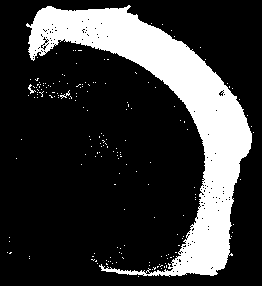

1it [00:04,  4.01s/it]

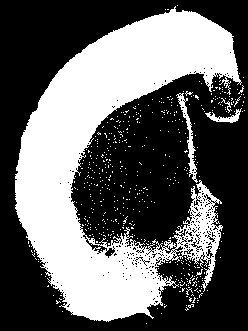

2it [00:08,  4.24s/it]

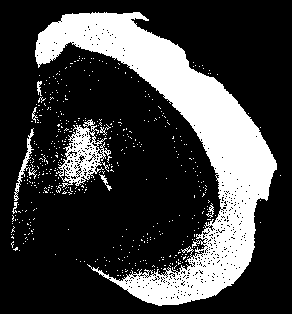

3it [00:13,  4.41s/it]

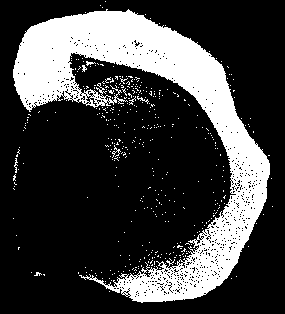

4it [00:17,  4.46s/it]


In [20]:
from msi_visual.normalization import total_ion_count, median_ion
mouse_values = []
masks = []
for mouse_index, (path, index) in tqdm.tqdm(enumerate(paths)):
    annotation_index = path.split("\\")[-1].split(".")[0]
    #img = np.load(path)
    img = get_img(path)
    rotated = img.transpose().transpose(1, 2, 0)[::-1, :, :]
    predictions = xgb_model.predict(rotated.reshape(-1, rotated.shape[-1])).reshape(rotated.shape[:2])
    mask = predictions == 3
    masks.append(np.uint8(mask) * 255)
    display(Image.fromarray(np.uint8(mask) * 255))
    mouse_values.append(rotated[mask].reshape(-1, rotated.shape[-1]))

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import scipy.stats
index = extraction_mzs.index(1161.8)

# Combine the first two and second two mice
group1_values = np.concatenate([mouse_values[0][:, index], mouse_values[1][:, index]])
group2_values = np.concatenate([mouse_values[2][:, index], mouse_values[3][:, index]])


result = scipy.stats.mannwhitneyu(
            group1_values, group2_values, keepdims=True, alternative="two-sided")
print(result)
us = result.statistic
auc = us / (group1_values.shape[0] * group2_values.shape[0])
p = result.pvalue
print(auc, p)



# Create histograms
plt.figure(figsize=(10, 5))
plt.hist([np.log(1e-5+ group1_values), np.log(1e-5+ group2_values)], bins=100, alpha=0.85, label=['A7KO POSITIVE', 'A7KO NEGATIVE'], density=True)
plt.xlabel('Log of Intensity (normalized with TIC)')
plt.ylabel('Density')
plt.title(f'Cortex Distribution of m/z {extraction_mzs[index]:.1f}')
plt.legend()
plt.show()


NameError: name 'extraction_mzs' is not defined

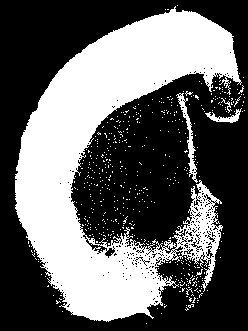

In [55]:
display(Image.fromarray(np.uint8(mask) * 255))

In [40]:
label_encoder.classes_

array(['BG', 'BS', 'CNU', 'CTX', 'HPF', 'PLEXUS', 'VENTRICLE', 'WM'],
      dtype='<U9')

In [5]:
stats

{('1_CTX', '2_CTX'): {323.0: 0.2781988883072209,
  347.0: 0.27061129110498416,
  937.4: 0.26077976138408643,
  965.6: 0.11367506190950051,
  966.6: 0.13912418881967756,
  967.6: 0.23123794494498956,
  987.4: 0.29048240408340154,
  1003.4: 0.2586746529276283,
  1043.4: 0.2822658181274689,
  1045.4: 0.18251741664868185,
  1046.4: 0.2018582731547813,
  1047.4: 0.2715784132669525,
  1067.4: 0.2566828325595822,
  1083.4: 0.25070244242502654,
  1084.4: 0.29926860600683847,
  1160.8: 0.14679247127128828,
  1161.0: 0.17927887208872054,
  1161.8: 0.20998385803619346,
  1162.0: 0.14796575483163574,
  1162.8: 0.29739411399482707,
  1163.0: 0.18525205809736559,
  1164.0: 0.25968243444326405,
  1165.0: 0.24311014541768014},
 ('1_CTX', '0_CTX'): {748.6: 0.22016992951515407,
  1158.8: 0.16306442485364006,
  1159.8: 0.2133980697624018,
  1160.8: 0.0867370701948304,
  1161.0: 0.13686522324427594,
  1161.8: 0.14417828079590617,
  1162.0: 0.09450356522216896,
  1162.8: 0.22537682357089514,
  1163.0: 0.12

In [58]:
print(stats.keys())
print(stats[('1_CTX', '0_CTX')][0][1179.8])
print(stats[('1_CTX', '0_CTX')][1][1179.8])


dict_keys([('1_CNU', '2_CNU'), ('1_CNU', '0_CNU'), ('1_CNU', '3_CNU'), ('1_VENTRICLE', '0_VENTRICLE'), ('1_VENTRICLE', '3_VENTRICLE'), ('1_VENTRICLE', '2_VENTRICLE'), ('2_HPF', '3_HPF'), ('2_HPF', '0_HPF'), ('2_HPF', '1_HPF'), ('0_BS', '1_BS'), ('0_BS', '2_BS'), ('0_BS', '3_BS'), ('3_HPF', '0_HPF'), ('3_HPF', '1_HPF'), ('0_WM', '1_WM'), ('0_WM', '3_WM'), ('0_WM', '2_WM'), ('1_WM', '3_WM'), ('1_WM', '2_WM'), ('1_BS', '2_BS'), ('1_BS', '3_BS'), ('2_BS', '3_BS'), ('1_CTX', '2_CTX'), ('1_CTX', '3_CTX'), ('1_CTX', '0_CTX'), ('2_PLEXUS', '3_PLEXUS'), ('2_PLEXUS', '1_PLEXUS'), ('3_WM', '2_WM'), ('2_BG', '3_BG'), ('2_BG', '0_BG'), ('2_BG', '1_BG'), ('3_PLEXUS', '1_PLEXUS'), ('0_VENTRICLE', '3_VENTRICLE'), ('0_VENTRICLE', '2_VENTRICLE'), ('2_CNU', '0_CNU'), ('2_CNU', '3_CNU'), ('2_CTX', '3_CTX'), ('2_CTX', '0_CTX'), ('3_VENTRICLE', '2_VENTRICLE'), ('0_CNU', '3_CNU'), ('3_CTX', '0_CTX'), ('0_HPF', '1_HPF'), ('3_BG', '0_BG'), ('3_BG', '1_BG'), ('0_BG', '1_BG')])


KeyError: 0

In [21]:
label_encoder.classes_

array(['BG', 'BS', 'CNU', 'CTX', 'HPF', 'PLEXUS', 'VENTRICLE', 'WM'],
      dtype='<U9')

In [85]:
for k in [k for k in stats.keys() if "CTX" in k[0]]:
    print(k, stats[k][1179.8])




('1_CTX', '2_CTX') 0.46075542149971527
('1_CTX', '3_CTX') 0.5430305163512341
('1_CTX', '0_CTX') 0.45458541926695845
('2_CTX', '3_CTX') 0.5825719477859407


KeyError: 1179.8

In [62]:
img0 = get_img("D:\\maldi\\slides\\slide2_notol_5_bin\\3.npy")
img2 = get_img("D:\\maldi\\slides\\slide2_notol_5_bin\\1.npy")

index = extraction_mzs.index(1180.0)


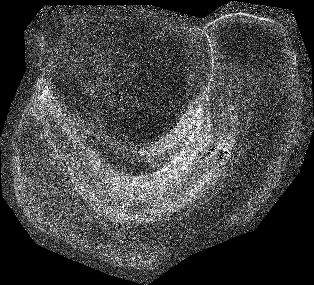

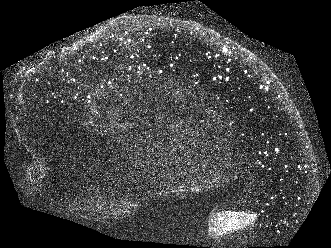

In [63]:
index = extraction_mzs.index(1179.8)
a = img0[:, :, index]
a = a / np.percentile(a[:], 99)
a[a > 1] = 1
b = img2[:, :, index]
b = b / np.percentile(b[:], 99)
b[b > 1] = 1

display(Image.fromarray(np.uint8(a * 255)))
display(Image.fromarray(np.uint8(b * 255)))





